In [1]:
import pandas as pd
import numpy as np

In [2]:
liepe_spliced = pd.read_csv("../data/GR-LCL Spliced.tsv", sep="\t")
liepe_not_spliced = pd.read_csv("../data/GR-LCL non-spliced.tsv", sep="\t")

liepe_spliced.head()

,ID,pep,length,Gene,Domain,Unnamed: 5,Unnamed: 6
0,32,AAAALGRAL,9,|P11831|SRF,8_14_17_18;|Q07065|CKAP4,87_90_104_108;|Q12772|SRBP2,NaN
1,1950,AAAELKLLLL,10,|P30679|GNA15,20_22_42_48,NaN,NaN
2,2803,AAAGIAKILLL,11,|Q9HCC8|GDPD2,164_169_188_192,NaN,NaN
3,3127,AAAGKLKSFAR,11,|O75448|MED24,453_455_459_466,NaN,NaN
4,2193,AAAHAPALRY,10,|Q9Y235|ABEC2,95_99_113_117,NaN,NaN


In [10]:
liepe_spliced['Category'] = 'Spliced'
liepe_not_spliced['Category'] = 'Non-spliced'

cols_liepe = ['pep', 'Category']



In [5]:
liepe = pd.concat([liepe_spliced, liepe_not_spliced])
liepe.shape

(10009, 9)

In [7]:
print(liepe_spliced.shape)
print(liepe_not_spliced.shape)


(3418, 8)
(6591, 9)


In [9]:
closed_search = pd.read_csv("../data/psm_filtered_classified.tsv", sep="\t")
closed_search.head(2)

,Spectrum,Peptide,Peptide Length,Protein ID,Protein,Gene,Mapped Proteins,Hyperscore,Nextscore,Qvalue,Probability,Delta Mass,SpectralSim,RTScore,Retention,Intensity,Is Decoy,Is Contaminant,DeltaScore,Class
0,GR_LCL_2D_ETHCD_fr2_immunopeptidome.02619.02619.2,AAAAGRIAI,9,P26599,sp|P26599|PTBP1_HUMAN,PTBP1,"tr|A0A087WTS6|A0A087WTS6_HUMAN, tr|A0A087WU68|...",30.797,24.737,0.00176,0.9805,-0.0014,0.9888,7.8471,3856.5366,770104.20,False,False,6.060,Swiss-Prot
1,GR_LCL_2D_ETHCD_fr2_immunopeptidome.04745.04745.2,AAAEPKLFGGF,11,P12931,sp|P12931|SRC_HUMAN,SRC,"sp|LIEPE-NOT-SPLICED-5388;|P12931|SRC;57_67, t...",46.747,18.599,0.00000,0.9999,0.0001,0.9456,5.1007,5801.0510,306523.25,False,False,28.148,Swiss-Prot


In [11]:
def assign_category(row):
    if row['Class'] == 'Spliced_only':
        return 'SPLICED'
    elif row['Class'] == 'Spliced_with_LIEPE-SPLICED_alternative':
        return 'SPLICED'
    else:
        return 'NOT_SPLICED'

closed_search["Category"] = closed_search.apply(assign_category, axis=1)

In [12]:
closed_search.head(2)

,Spectrum,Peptide,Peptide Length,Protein ID,Protein,Gene,Mapped Proteins,Hyperscore,Nextscore,Qvalue,...,Delta Mass,SpectralSim,RTScore,Retention,Intensity,Is Decoy,Is Contaminant,DeltaScore,Class,Category
0,GR_LCL_2D_ETHCD_fr2_immunopeptidome.02619.02619.2,AAAAGRIAI,9,P26599,sp|P26599|PTBP1_HUMAN,PTBP1,"tr|A0A087WTS6|A0A087WTS6_HUMAN, tr|A0A087WU68|...",30.797,24.737,0.00176,...,-0.0014,0.9888,7.8471,3856.5366,770104.20,False,False,6.060,Swiss-Prot,NOT_SPLICED
1,GR_LCL_2D_ETHCD_fr2_immunopeptidome.04745.04745.2,AAAEPKLFGGF,11,P12931,sp|P12931|SRC_HUMAN,SRC,"sp|LIEPE-NOT-SPLICED-5388;|P12931|SRC;57_67, t...",46.747,18.599,0.00000,...,0.0001,0.9456,5.1007,5801.0510,306523.25,False,False,28.148,Swiss-Prot,NOT_SPLICED


In [13]:
cols_closed = ['Peptide', 'Category']

In [15]:
closed_search = closed_search[cols_closed]
liepe = liepe[cols_liepe]

print(closed_search.shape)
print(liepe.shape)




(10748, 2)
(10009, 2)


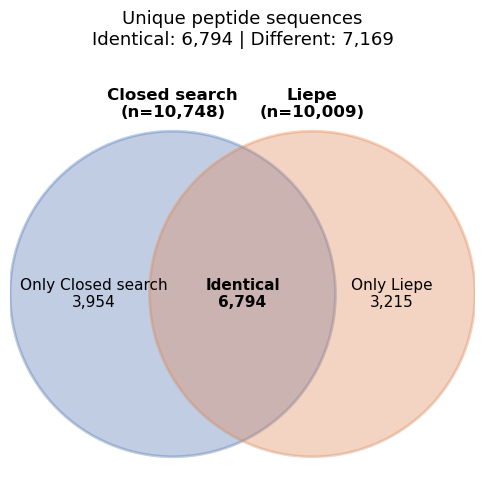

In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


def plot_euler_diagram(only_left, overlap, only_right, left_label, right_label, left_n, right_n, title):
    different = only_left + only_right
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.add_patch(Circle((0.35, 0.5), 0.35, facecolor="#4C72B0", alpha=0.35, edgecolor="#4C72B0", lw=2))
    ax.add_patch(Circle((0.65, 0.5), 0.35, facecolor="#DD8452", alpha=0.35, edgecolor="#DD8452", lw=2))

    ax.text(0.18, 0.5, f"Only {left_label}\n{only_left:,}", ha="center", va="center", fontsize=11)
    ax.text(0.5, 0.5, f"Identical\n{overlap:,}", ha="center", va="center", fontsize=11, fontweight="bold")
    ax.text(0.82, 0.5, f"Only {right_label}\n{only_right:,}", ha="center", va="center", fontsize=11)
    ax.text(0.35, 0.88, f"{left_label}\n(n={left_n:,})", ha="center", fontsize=12, fontweight="bold")
    ax.text(0.65, 0.88, f"{right_label}\n(n={right_n:,})", ha="center", fontsize=12, fontweight="bold")

    ax.set_xlim(0, 1)
    ax.set_ylim(0.1, 1)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"{title}\nIdentical: {overlap:,} | Different: {different:,}", fontsize=13, pad=12)
    plt.tight_layout()
    plt.show()


closed_peptides = set(closed_search["Peptide"])
liepe_peptides = set(liepe["pep"])

identical_sequences = closed_peptides & liepe_peptides
only_closed_sequences = closed_peptides - liepe_peptides
only_liepe_sequences = liepe_peptides - closed_peptides

plot_euler_diagram(
    only_left=len(only_closed_sequences),
    overlap=len(identical_sequences),
    only_right=len(only_liepe_sequences),
    left_label="Closed search",
    right_label="Liepe",
    left_n=len(closed_peptides),
    right_n=len(liepe_peptides),
    title="Unique peptide sequences",
)

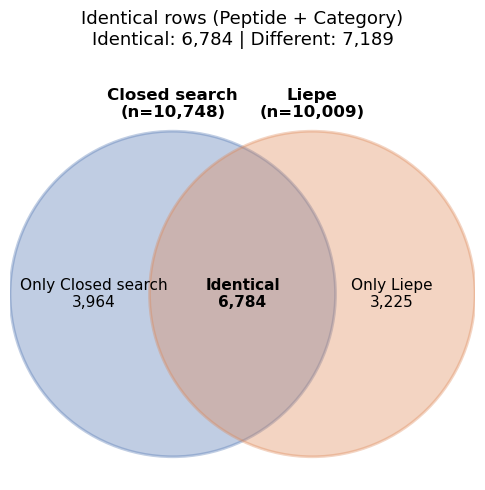

In [17]:
liepe_rows = liepe.rename(columns={"pep": "Peptide"}).copy()
liepe_rows["Category"] = liepe_rows["Category"].map(
    {"Spliced": "SPLICED", "Non-spliced": "NOT_SPLICED"}
)

identical_rows = pd.merge(closed_search, liepe_rows, on=["Peptide", "Category"], how="inner")
only_closed_rows = (
    pd.merge(closed_search, liepe_rows, on=["Peptide", "Category"], how="left", indicator=True)
    .query("_merge == 'left_only'")
    .shape[0]
)
only_liepe_rows = (
    pd.merge(liepe_rows, closed_search, on=["Peptide", "Category"], how="left", indicator=True)
    .query("_merge == 'left_only'")
    .shape[0]
)

plot_euler_diagram(
    only_left=only_closed_rows,
    overlap=len(identical_rows),
    only_right=only_liepe_rows,
    left_label="Closed search",
    right_label="Liepe",
    left_n=len(closed_search),
    right_n=len(liepe_rows),
    title="Identical rows (Peptide + Category)",
)